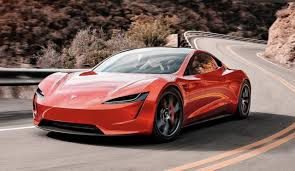

## Machine Learning 

### Cross Validation 

In this project, we'll cover:

* Chain multiple data processing steps together using `Pipeline`
* Use the `KFolds` object to split data into multiple folds.

### Load python librarie

In [176]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import boxcox
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

**Set a directory**

In [177]:
def  plot_dis(y,yhat):
    
    plt.figure()
    ax1 = sns.distplot(y, hist=False, color="r", label="Actual Value")
    sns.distplot(yhat, hist=False, color="b", label="Fitted Values" , ax=ax1)
    plt.legend()

    plt.title('Actual vs Fitted Values')
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')

    plt.show()
    plt.close()

#### Load the dataset

In [178]:
url = "https://raw.githubusercontent.com/JoshuaKab/Kaggle_project/main/ai_jobs_salaries_clean.csv"

data = pd.read_csv(url, encoding="latin-1")

In [179]:
data.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M,Executive-level,Full-time,On-site,True,Analytics Manager,Information and communications technology serv...
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M,Executive-level,Full-time,On-site,False,Analytics Manager,Information and communications technology serv...
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M,Mid-level,Full-time,Remote,False,Other / Unclassified,NaN


## **Data Cleaning and Wrangling**

Here, we'll check if there's missing value, duplicates, etc...

Removed duplicated values

In [180]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 71913 entries, 0 to 71912
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   work_year               71913 non-null  int64
 1   experience_level        71913 non-null  str  
 2   employment_type         71913 non-null  str  
 3   job_title               71913 non-null  str  
 4   salary                  71913 non-null  int64
 5   salary_currency         71913 non-null  str  
 6   salary_in_usd           71913 non-null  int64
 7   employee_residence      71913 non-null  str  
 8   remote_ratio            71913 non-null  int64
 9   company_location        71913 non-null  str  
 10  company_size            71913 non-null  str  
 11  experience_level_label  71913 non-null  str  
 12  employment_type_label   71913 non-null  str  
 13  work_mode               71913 non-null  str  
 14  salary_outlier_flag     71913 non-null  bool 
 15  role_family             71913 

In [181]:
data.isna().sum()

work_year                     0
experience_level              0
employment_type               0
job_title                     0
salary                        0
salary_currency               0
salary_in_usd                 0
employee_residence            0
remote_ratio                  0
company_location              0
company_size                  0
experience_level_label        0
employment_type_label         0
work_mode                     0
salary_outlier_flag           0
role_family                   0
isco_group_hint           40540
dtype: int64

Delete isco_group_hint column

In [182]:
data.drop(['isco_group_hint'], axis=1, inplace=True)

In [183]:
data.columns.tolist()

['work_year',
 'experience_level',
 'employment_type',
 'job_title',
 'salary',
 'salary_currency',
 'salary_in_usd',
 'employee_residence',
 'remote_ratio',
 'company_location',
 'company_size',
 'experience_level_label',
 'employment_type_label',
 'work_mode',
 'salary_outlier_flag',
 'role_family']

In [184]:
data.isna().sum()

work_year                 0
experience_level          0
employment_type           0
job_title                 0
salary                    0
salary_currency           0
salary_in_usd             0
employee_residence        0
remote_ratio              0
company_location          0
company_size              0
experience_level_label    0
employment_type_label     0
work_mode                 0
salary_outlier_flag       0
role_family               0
dtype: int64

In [185]:
#check for duplicate
data.duplicated().sum()

np.int64(0)

There is no duplicates and no missing value

Well the data has been we structure now we can move on to EDA

In [186]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
work_year,71913.0,2024.425153,0.721198,2020.0,2024.0,2025.0,2025.0,2025.0
salary,71913.0,161710.163823,287286.815546,14000.0,96400.0,139700.0,192200.0,30400000.0
salary_in_usd,71913.0,151161.252625,77329.594122,15000.0,96000.0,138750.0,190315.0,800000.0
remote_ratio,71913.0,24.569271,42.917779,0.0,0.0,0.0,0.0,100.0


In [187]:
for col in data.columns:
    print(f"\n{col}")
    print(data[col].nunique())


work_year
6

experience_level
4

employment_type
4

job_title
422

salary
12308

salary_currency
26

salary_in_usd
13580

employee_residence
104

remote_ratio
3

company_location
97

company_size
3

experience_level_label
4

employment_type_label
4

work_mode
3

salary_outlier_flag
2

role_family
11


In [188]:
categorical_cols = data.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(data[col].value_counts(dropna=False).head(20))


===== experience_level =====
experience_level
SE    37702
MI    23395
EN     7975
EX     2841
Name: count, dtype: int64

===== employment_type =====
employment_type
FT    71163
CT      383
PT      351
FL       16
Name: count, dtype: int64

===== job_title =====
job_title
Data Scientist               7160
Data Engineer                7071
Data Analyst                 6405
Software Engineer            4921
Engineer                     4375
Manager                      3612
Machine Learning Engineer    3462
Analyst                      2783
Research Scientist           1381
Analytics Engineer           1341
Product Manager              1326
Associate                    1238
Data Architect               1231
AI Engineer                  1163
Research Engineer             887
Consultant                    783
Developer                     715
Data Manager                  697
Data Specialist               669
Systems Engineer              563
Name: count, dtype: int64

===== salary_currenc

In [189]:
print("Check the dataset size and numerical variables")

print("Rows:", len(data))
print("Columns:", len(data.columns))

print("\nNumerical columns:")
print(data.select_dtypes(include="number").columns.tolist())

print("\nCategorical columns:")
print(data.select_dtypes(include="object").columns.tolist())

Check the dataset size and numerical variables
Rows: 71913
Columns: 16

Numerical columns:
['work_year', 'salary', 'salary_in_usd', 'remote_ratio']

Categorical columns:
['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size', 'experience_level_label', 'employment_type_label', 'work_mode', 'role_family']


In [190]:
data[['job_title','role_family']].head(50)

,job_title,role_family
0,Head of Data,Analytics Manager
1,Head of Data,Analytics Manager
2,Data Scientist,Data Scientist
3,Data Scientist,Data Scientist
4,Engineer,Other / Unclassified
5,Engineer,Other / Unclassified
6,AI Product Lead,Other / Unclassified
7,AI Product Lead,Other / Unclassified
8,AI Engineer,AI Engineer
9,AI Engineer,AI Engineer


In [191]:
other_roles = (
    data.loc[
        data["role_family"] == "Other / Unclassified",
        "job_title"
    ]
    .value_counts()
)

print(other_roles.head(50))

job_title
Software Engineer                4921
Engineer                         4375
Manager                          3612
Analyst                          2783
Analytics Engineer               1341
Product Manager                  1326
Associate                        1238
Data Architect                   1231
Consultant                        783
Developer                         715
Data Manager                      697
Data Specialist                   669
Systems Engineer                  563
Architect                         543
Engineering Manager               524
Software Developer                523
Director                          512
Solutions Architect               436
Platform Engineer                 411
Software Development Engineer     409
DevOps Engineer                   382
Machine Learning Scientist        359
Business Analyst                  350
Site Reliability Engineer         333
Research Analyst                  321
Data Governance                   294
So

In [192]:
for col in data.describe(include='object').columns:
    #print(col)
    print(data[col].value_counts(normalize=True)*100)
    print('-'*30)

experience_level
SE    52.427238
MI    32.532365
EN    11.089789
EX     3.950607
Name: proportion, dtype: float64
------------------------------
employment_type
FT    98.957073
CT     0.532588
PT     0.488090
FL     0.022249
Name: proportion, dtype: float64
------------------------------
job_title
Data Scientist              9.956475
Data Engineer               9.832715
Data Analyst                8.906595
Software Engineer           6.842991
Engineer                    6.083740
                              ...   
Deep Learning Researcher    0.001391
Marketing Data Engineer     0.001391
Data Science Tech Lead      0.001391
Principal Data Architect    0.001391
Cloud Data Architect        0.001391
Name: proportion, Length: 422, dtype: float64
------------------------------
salary_currency
USD    91.652413
GBP     3.780958
EUR     3.153811
CAD     0.792624
INR     0.190508
PLN     0.127932
CHF     0.059794
AUD     0.045889
PHP     0.040327
BRL     0.027811
SGD     0.023640
JPY     0.0180

### What stands out
The dataset is heavily US-centric.
employee_residence and company_location are dominated by the US (~60k of ~72k records). Country-level comparisons will therefore be highly imbalanced.

Company size is extremely imbalanced.

* M: 70,110
* L: 1,588
* S: 215

A model can easily learn that almost everything is "M", so we'll need to treat this carefully.

Employment type is almost entirely full-time.

* FT: 71,163
* CT: 383
* PT: 351
* FL: 16

We should probably not make employment type a major analytical question, because the minority groups are very small.

Work mode is also highly imbalanced.

* On-site: 54,081
* Remote: 17,505
* Hybrid: 327

Hybrid is particularly sparse.

experience_level and experience_level_label are duplicates conceptually.
For example:
> SE → Senior-level, MI → Mid-level, etc. We should retain one representation for modeling, not both.
role_family is potentially much more useful than raw job_title.

> You have thousands of job-title variations, while role_family gives us a manageable set of categories. However, "Other / Unclassified" contains ~40,540 records, so we need to investigate how that category was generated.

> Currency is overwhelmingly USD.
This is actually helpful for salary modeling because you already have salary_in_usd. For salary prediction, I would use salary_in_usd as the target and generally exclude the original salary and salary_currency.

### Check salary quality

This is particularly important because salary will be our target.

In [193]:
print(data["salary_in_usd"].describe(
    percentiles=[
        .01, .05, .10, .25,
        .50,
        .75, .90, .95, .99
    ]
))

count     71913.000000
mean     151161.252625
std       77329.594122
min       15000.000000
1%        31988.560000
5%        53718.600000
10%       67500.000000
25%       96000.000000
50%      138750.000000
75%      190315.000000
90%      250000.000000
95%      290000.000000
99%      391000.000000
max      800000.000000
Name: salary_in_usd, dtype: float64


In [194]:
print(
    "Salary <= 0:",
    (data["salary_in_usd"] <= 0).sum()
)

print(
    "Salary missing:",
    data["salary_in_usd"].isna().sum()
)

print(
    data.nlargest(20, "salary_in_usd")[
        [
            "work_year",
            "experience_level_label",
            "job_title",
            "salary",
            "salary_currency",
            "salary_in_usd",
            "employee_residence",
            "company_location",
            "company_size",
            "role_family"
        ]
    ]
)

Salary <= 0: 0
Salary missing: 0
       work_year experience_level_label                   job_title  salary  \
18840       2025           Senior-level                   Architect  800000   
29167       2025           Senior-level           Software Engineer  800000   
64828       2024              Mid-level                AI Architect  800000   
35589       2025            Entry-level               Data Engineer  753480   
65151       2024            Entry-level                Data Analyst  774000   
1898        2025           Senior-level  Machine Learning Scientist  750000   
7771        2025           Senior-level              Data Scientist  750000   
10111       2025              Mid-level           Software Engineer  750000   
15734       2025              Mid-level   Machine Learning Engineer  750000   
21408       2025           Senior-level   Machine Learning Engineer  750000   
22004       2025              Mid-level           Software Engineer  750000   
23314       2025   

In [195]:
print(data["salary_outlier_flag"].value_counts(dropna=False))

salary_outlier_flag
False    70159
True      1754
Name: count, dtype: int64


In [196]:
pd.crosstab(
    data["salary_outlier_flag"],
    data["experience_level_label"],
    normalize="index"
)

experience_level_label,Entry-level,Executive-level,Mid-level,Senior-level
salary_outlier_flag,,,,
False,0.112986,0.037600,0.327413,0.522000
True,0.027366,0.115735,0.241733,0.615165


### country variables need careful treatment

You have:

`employee_residence`
`company_location`

These are potentially powerful predictors.

But the distribution is heavily dominated by the US.

Therefore, don't immediately make an analysis like:

"Which country pays the highest salary?"

because countries with tiny sample sizes can produce misleading averages.

Instead, establish a minimum sample threshold.

In [197]:
country_counts = data["company_location"].value_counts()

valid_countries = country_counts[
    country_counts >= 100
].index

country_salary = (
    data[data["company_location"].isin(valid_countries)]
    .groupby("company_location")["salary_in_usd"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

country_salary

,count,mean,median
company_location,,,
US,60147,160275.470165,147200.0
CA,4571,130319.582148,119875.0
AU,511,126349.086106,117000.0
IE,125,109692.248000,97473.0
DE,400,101561.730000,85000.0
GB,2835,98752.944621,76202.0
PL,147,76628.639456,74000.0
NL,398,80526.743719,72265.0
FR,302,71849.456954,58113.5


In [198]:
pd.crosstab(
    data["remote_ratio"],
    data["work_mode"],
    normalize="index"
)

work_mode,Hybrid,On-site,Remote
remote_ratio,,,
0,0.0,1.0,0.0
50,1.0,0.0,0.0
100,0.0,0.0,1.0


### EXPLORATORY DATA ANALYSIS(EDA

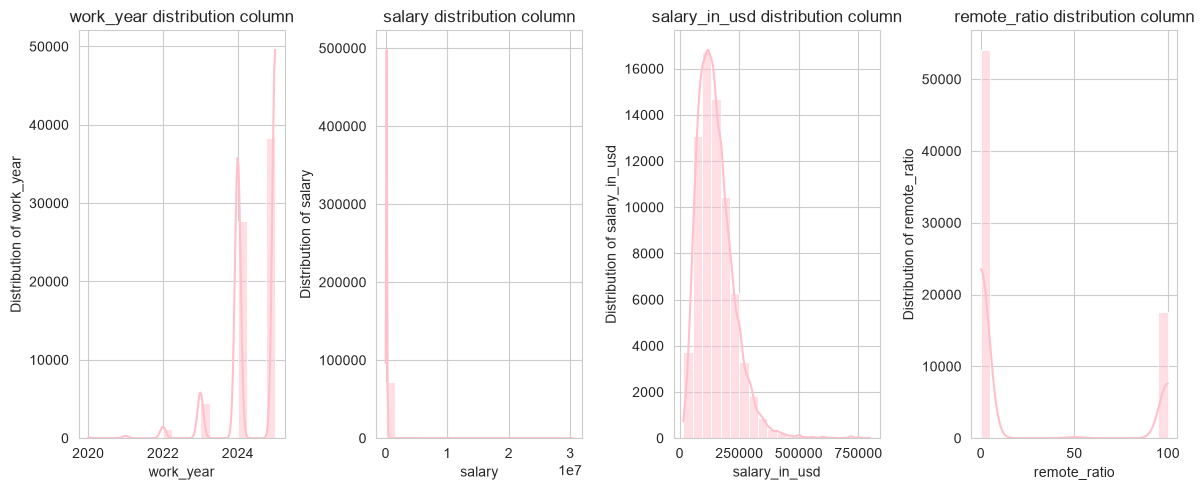

In [199]:
#Data exploratory analys
numerical_features = data.select_dtypes(include='number').columns.tolist()  # Example to get numberic features

sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))

# Loop through numerical features
for i, column in enumerate(numerical_features, start=1):  # Use enumerate to get the index
    plt.subplot(1, 4, i)  # Adjust the number of rows and columns as needed
    sns.histplot(data[column], bins=20, kde=True, color='pink')
    plt.title(f'{column} distribution column')
    plt.xlabel(column)
    plt.ylabel(f'Distribution of {column}')

plt.tight_layout()
plt.show()

## Looking for Correlations

Let's check how the data are correlated

In [200]:
df_corr = data.select_dtypes(include = ['float64', 'int64'])
df_num_corr = df_corr.corr()['salary_in_usd'] # -1 means that the latest row is price
top_features = df_num_corr[abs(df_num_corr) > 0.1].sort_values(ascending=False) #displays pearsons correlation coefficient 
print("There is {} strongly correlated values with price:\n{}".format(len(top_features), top_features))

There is 2 strongly correlated values with price:
salary_in_usd    1.000000
salary           0.224115
Name: salary_in_usd, dtype: float64


In [201]:
data['remote_ratio'].unique()

array([  0, 100,  50])

<Axes: xlabel='remote_category'>

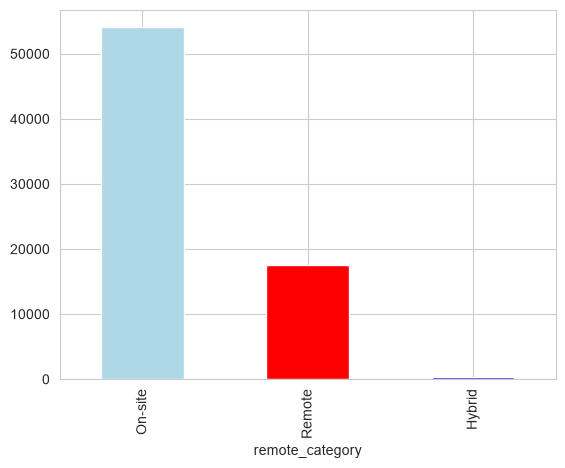

In [202]:
#we'll add salary category that discribe salary range, Low, Mid_range and High
data['salary_category'] = data['salary_in_usd'].apply(lambda x : "Low" if x < 60000 
                                                     else ("Mid_Range" if 60000 <= x < 120000
                                                           else "High"))

remote_mapping = {
    0: "On-site",
    50: "Hybrid",
    100: "Remote"
}

data["remote_category"] = data["remote_ratio"].map(remote_mapping)
data["remote_category"].value_counts().plot.bar(color=['lightblue', 'red', 'blue'])

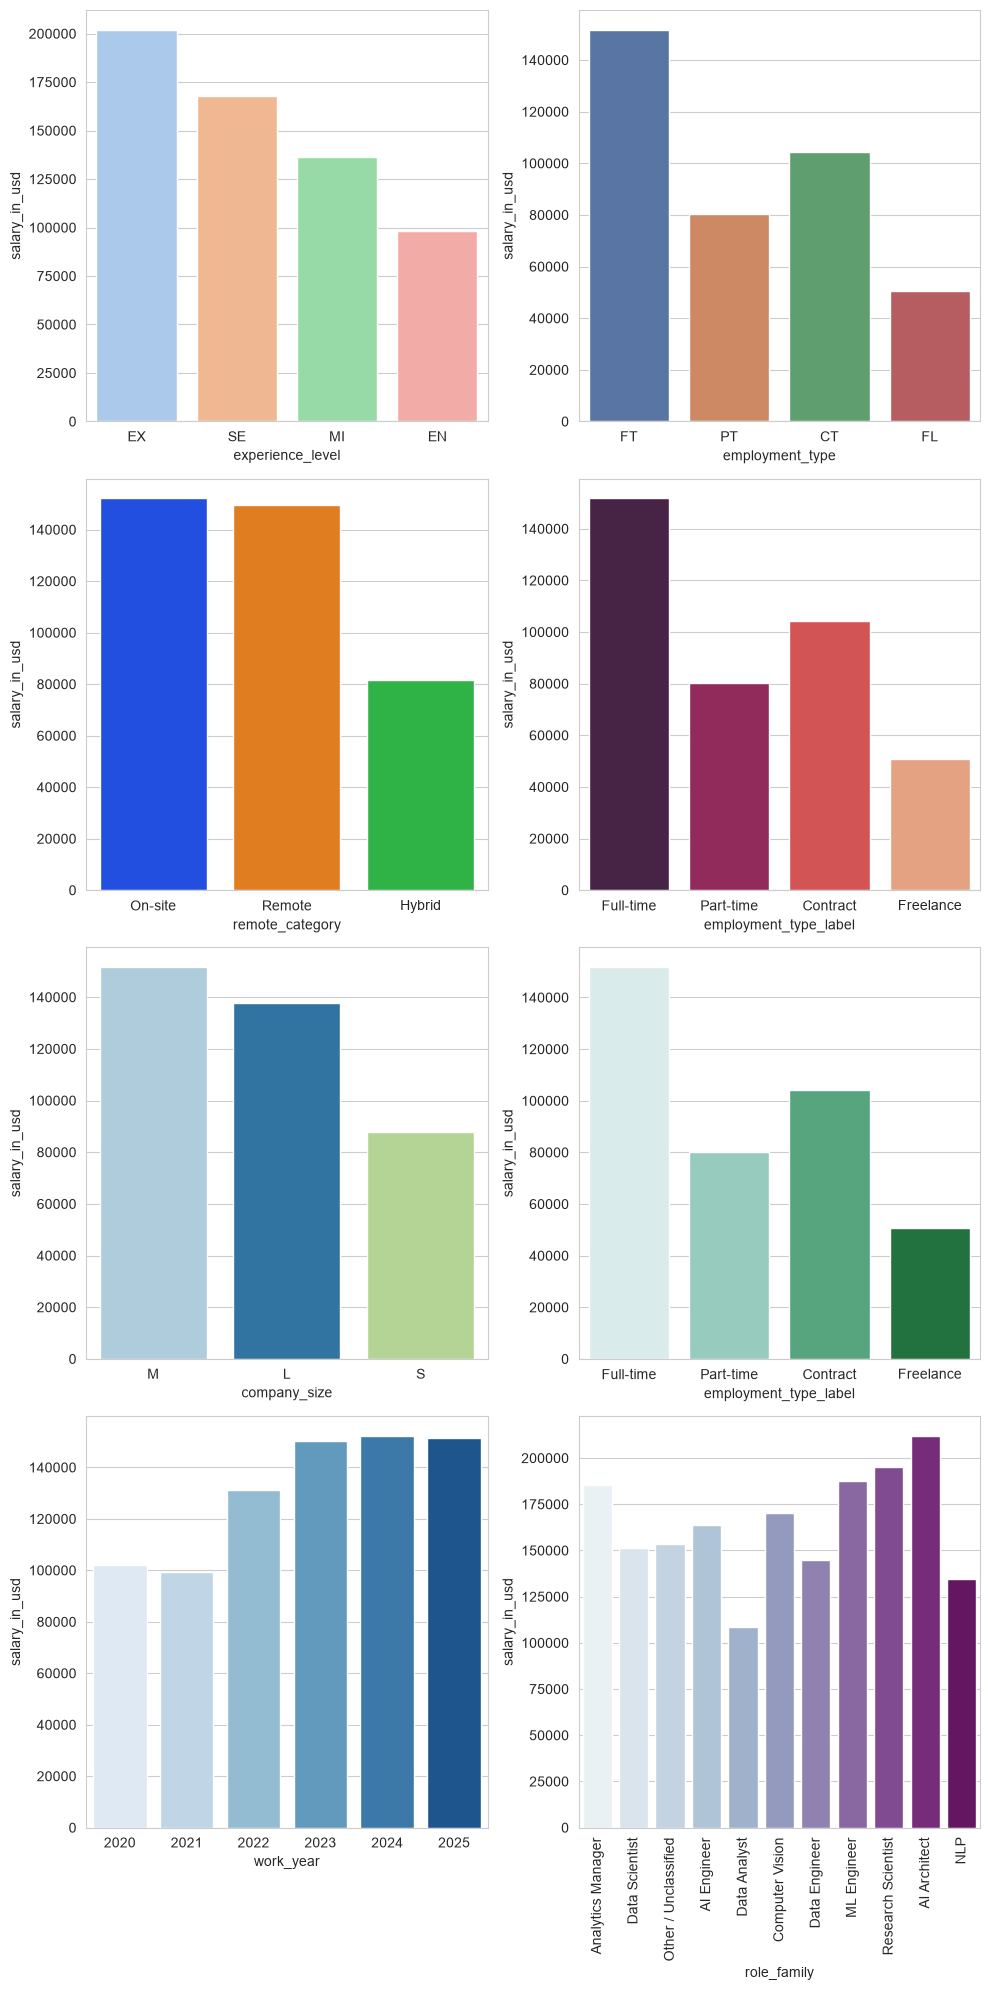

In [203]:
plt.figure(figsize=(10, 20))
plt.subplot(4,2,1)
sns.barplot(x = 'experience_level', y = 'salary_in_usd', palette="pastel", data = data, estimator="mean", errorbar=None)
plt.subplot(4,2,2)
sns.barplot(x = 'employment_type', y = 'salary_in_usd', palette="deep", data = data, estimator="mean", errorbar=None)
plt.subplot(4,2,3)
sns.barplot(x = 'remote_category', y = 'salary_in_usd', palette="bright", data = data, estimator="mean", errorbar=None)
plt.subplot(4,2,4)
sns.barplot(x = 'employment_type_label', y = 'salary_in_usd', palette="rocket", data = data, estimator="mean", errorbar=None)
plt.subplot(4,2,5)
sns.barplot(x = 'company_size', y = 'salary_in_usd', palette="Paired", data = data, estimator="mean", errorbar=None)
plt.subplot(4,2,6)
sns.barplot(x = 'employment_type_label', y = 'salary_in_usd', palette="BuGn", data = data, estimator="mean", errorbar=None)
plt.subplot(4,2,7)
sns.barplot(x = 'work_year', y = 'salary_in_usd', palette="Blues", data = data, estimator="mean", errorbar=None)
plt.subplot(4,2,8)
sns.barplot(x = 'role_family', y = 'salary_in_usd', palette="BuPu", data = data, estimator="mean", errorbar=None)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

There are some typos in the names of the cars, so they should be corrected.


In [204]:
# Group by brand and transmission, and calculate count, mean, and sum of prices
model = data.groupby(["role_family", "remote_category"])["salary_in_usd"].agg(['count', 'mean', 'sum']).reset_index()

# Create a DataFrame from the model and apply a background gradient style
model_price = pd.DataFrame(model)
model_price


,role_family,remote_category,count,mean,sum
0,AI Architect,On-site,161,220463.453416,35494616
1,AI Architect,Remote,58,188763.258621,10948269
2,AI Engineer,Hybrid,7,93850.000000,656950
3,AI Engineer,On-site,893,167794.689810,149840658
4,AI Engineer,Remote,309,154009.676375,47588990
5,Analytics Manager,Hybrid,4,119144.000000,476576
6,Analytics Manager,On-site,353,186283.308782,65758008
7,Analytics Manager,Remote,138,184478.413043,25458021
8,Computer Vision,Hybrid,2,23841.000000,47682
9,Computer Vision,On-site,106,181792.207547,19269974


Average price on the brand categories

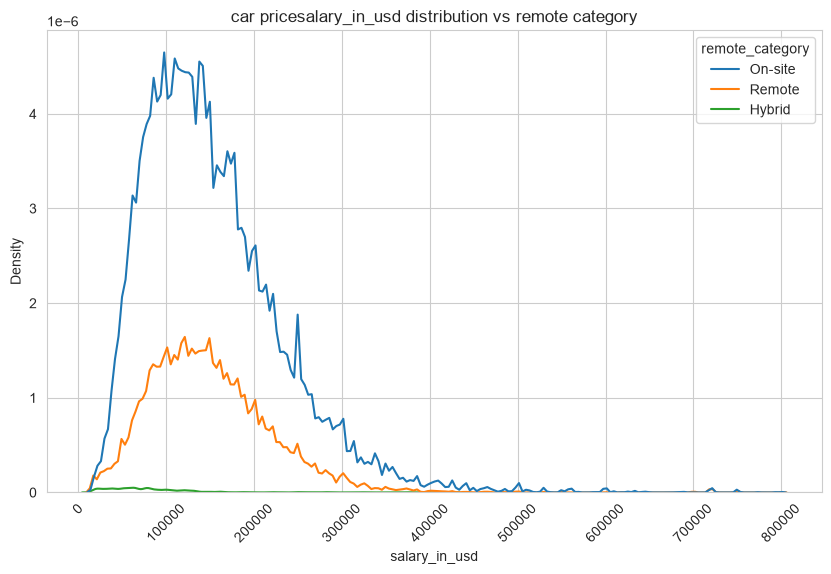

In [205]:
#trand on car brand vs sale price  
plt.figure(figsize=(10,6))
sns.kdeplot(data=data, x = 'salary_in_usd', hue="remote_category", bw_adjust=.2)
plt.xticks(rotation=45)
plt.title('car pricesalary_in_usd distribution vs remote category')
plt.show()

INSIGHT

Price compare with mileage column plus  the engine size and transmission, which we find out that automatic and Semi auto, are the most expensives vehicles yet with the loweest mileage.

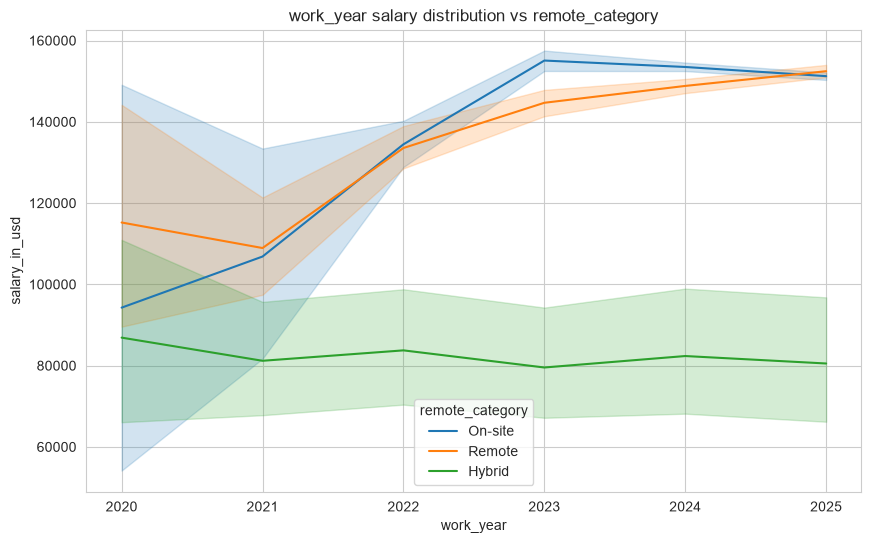

In [206]:
plt.figure(figsize=(10,6))
sns.lineplot(data, x='work_year', y='salary_in_usd', hue='remote_category')
plt.title('work_year salary distribution vs remote_category')
plt.show()

INSIGHT

* 2001 is the year when car prices were abnormally decreased, but just after 2003, car prices started to regain their position in the market. With this in mind, since 2005, the hybrid fuel type has been rapidly increasing due to the popular demand, but diesel is still on top of the ranks

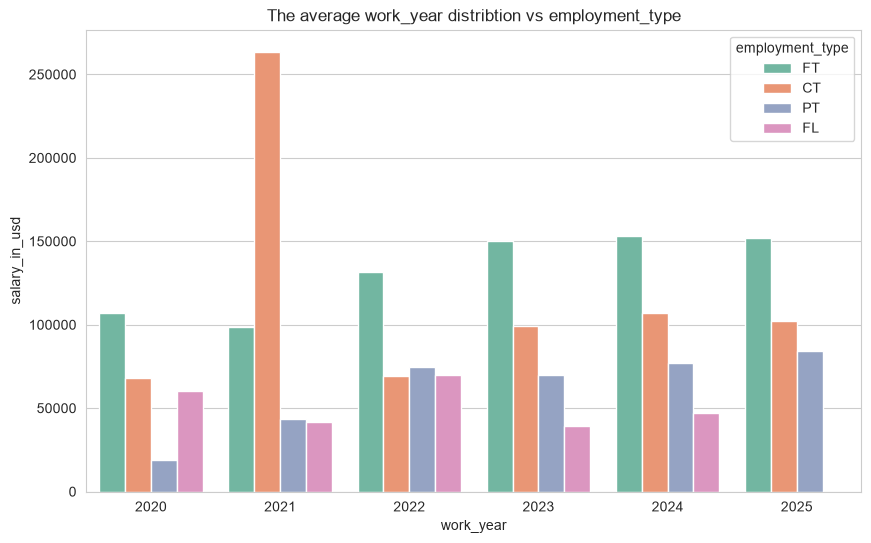

In [207]:
plt.figure(figsize=(10,6))
sns.barplot(data, x='work_year', y='salary_in_usd', hue='employment_type', palette='Set2', estimator="mean", errorbar=None)
plt.title('The average work_year distribtion vs employment_type')
plt.show()

## wordCloud 



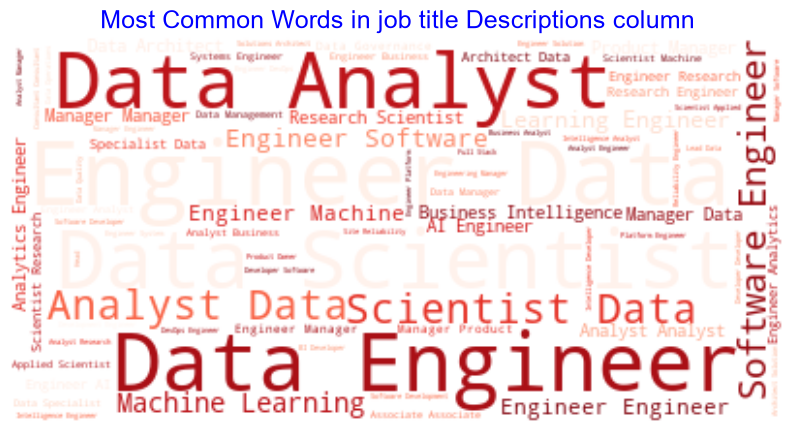

In [208]:
from wordcloud import WordCloud

titles = data['job_title'].values

text = ' '.join(titles)

wordcloud = WordCloud(background_color='white', colormap='Reds', max_words = 200).generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in job title Descriptions column', color='blue', size=18)
plt.show();


## Machine learning Model

In [209]:
categorical_cols

Index(['experience_level', 'employment_type', 'job_title', 'salary_currency',
       'employee_residence', 'company_location', 'company_size',
       'experience_level_label', 'employment_type_label', 'work_mode',
       'role_family'],
      dtype='str')

In [210]:
#select features for machine learning
from sklearn.preprocessing import LabelEncoder

categorical_features = data.select_dtypes(exclude=np.number)

Le = LabelEncoder()

for column in categorical_features:
    data[column] = Le.fit_transform(data[column].astype(str))

In [211]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = data.drop("salary_in_usd", axis=1)
y = data["salary_in_usd"]



# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Fit preprocessing ONLY on training data
#X_train = preprocessor.fit_transform(X_train)

# Transform test data
#X_test = preprocessor.transform(X_test)



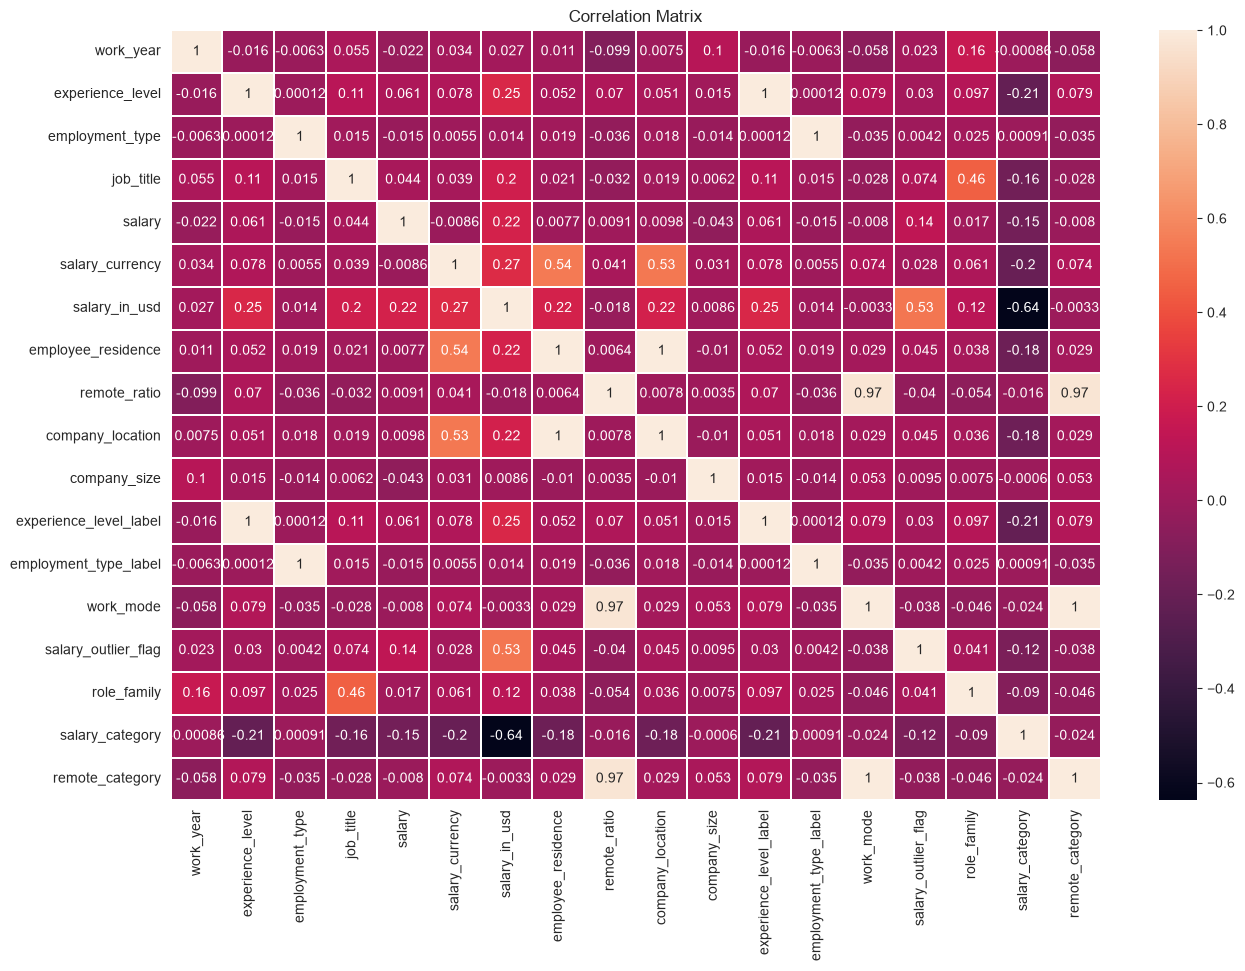

In [212]:
#Plot correlation matrix
plt.figure(figsize=(15,10))
df= data.corr()
sns.heatmap(df, annot=True, linewidth=0.02)
plt.title("Correlation Matrix")
plt.show()

### LinearRegression

In [213]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np


# Create an instance of the LinearRegression model
lr = LinearRegression()

# Fit the model on the training data
lr.fit(X_train, y_train)
    
# Predict on the test data
y_pred = lr.predict(X_test)



In [214]:
# Assuming lr is your fitted linear regression model and X is your feature DataFrame
coef = lr.coef_  # Get the coefficients from the linear regression model
column = X.columns  # Get the feature names

# Create a DataFrame with feature names and their corresponding coefficients
df_ = pd.DataFrame({'Feature': column, 'Coefficient': coef})

# Reset the index if needed (not necessary here since we are creating a new DataFrame)
df_ = df_.reset_index(drop=True).sort_values(by='Coefficient')

# Display the DataFrame
print(df_)

                   Feature   Coefficient
15         salary_category -45979.956409
8         company_location   -299.817378
7             remote_ratio    -62.293601
2          employment_type    -13.906820
11   employment_type_label    -13.906820
4                   salary      0.040845
14             role_family     32.362170
3                job_title     59.074384
9             company_size     90.445360
12               work_mode    162.925257
16         remote_category    162.925257
6       employee_residence    417.084177
13     salary_outlier_flag    712.753375
0                work_year   1673.148801
5          salary_currency   1936.197967
10  experience_level_label   4114.209880
1         experience_level   4114.209880


### Multiple features

Let's create a <code>LinearRegression</code> object, called `lm`.


We apply `predict(`) function on the testing data set.

Let's calculate the `r2_score()` on both, training and testing data sets.

In [215]:
print("R^2 on training  data ",lr.score(X_train, y_train))
print("R^2 on testing data ",lr.score(X_test,y_test))

R^2 on training  data  0.47005820593972736
R^2 on testing data  0.46129557436479063


# Pipeline

We can also use the pipeline to run operations on our data. For example we can standardize our data then perform linear regression by applying the method <code>fit</code>.

In [216]:
pipe = Pipeline([('ss',StandardScaler() ),('lr', LinearRegression())])
pipe.fit(X_train,y_train)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ss', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['work_year','experience_level','employment_type',...,'role_family', 'salary_category','remote_category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [217]:
pipe.score(X_train,y_train)

0.6558145219363567

Using the training data only, the R squared is \~ 0.77.\
Now, let's check the R squared on the test set.

In [218]:
pipe.score(X_test,y_test)

0.6557470587945569

The R squared is 0.77. This value provides more accurate evaluation of our model since we test our model on the 'unseen' data set. visit this [documentation](https://en.wikipedia.org/wiki/Overfitting?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) on overfitting.




In [219]:
# Enter your code and run the cell
pipe_1 = Pipeline([('nn',Normalizer() ),('lr', LinearRegression())])
pipe_1.fit(X_train, y_train)

pipe_1.score(X_train,y_train)
pipe_1.score(X_test,y_test)

pred =pipe_1.predict(X_test)

mse = mean_squared_error(y_true=y_test, y_pred=pred)
rmse = np.sqrt(mse)
rmse

np.float64(35154.60944695292)

We can use the test data to select a feature with the best performance. We have a list of features:


In [220]:
features=list(X)
features

['work_year',
 'experience_level',
 'employment_type',
 'job_title',
 'salary',
 'salary_currency',
 'employee_residence',
 'remote_ratio',
 'company_location',
 'company_size',
 'experience_level_label',
 'employment_type_label',
 'work_mode',
 'salary_outlier_flag',
 'role_family',
 'salary_category',
 'remote_category']

In [221]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

R_2_train = []
R_2_test = []

pipe = Pipeline([
    ('ss', StandardScaler()),
    ('lr', LinearRegression())
])

for feature in features:
    # Train using one feature
    pipe.fit(X_train[[feature]], y_train)

    # Training R²
    train_r2 = pipe.score(X_train[[feature]], y_train)
    R_2_train.append(train_r2)

    # Test R²
    test_r2 = pipe.score(X_test[[feature]], y_test)
    R_2_test.append(test_r2)

# Display results
for feature, train_r2, test_r2 in zip(features, R_2_train, R_2_test):
    print(
        f"{feature}: "
        f"Train R² = {train_r2:.4f}, "
        f"Test R² = {test_r2:.4f}"
    )

    

work_year: Train R² = 0.0007, Test R² = 0.0008
experience_level: Train R² = 0.0620, Test R² = 0.0588
employment_type: Train R² = 0.0001, Test R² = 0.0003
job_title: Train R² = 0.0415, Test R² = 0.0372
salary: Train R² = 0.0592, Test R² = 0.0253
salary_currency: Train R² = 0.0705, Test R² = 0.0730
employee_residence: Train R² = 0.0484, Test R² = 0.0510
remote_ratio: Train R² = 0.0002, Test R² = 0.0005
company_location: Train R² = 0.0472, Test R² = 0.0499
company_size: Train R² = 0.0001, Test R² = 0.0000
experience_level_label: Train R² = 0.0620, Test R² = 0.0588
employment_type_label: Train R² = 0.0001, Test R² = 0.0003
work_mode: Train R² = 0.0000, Test R² = -0.0000
salary_outlier_flag: Train R² = 0.2784, Test R² = 0.2822
role_family: Train R² = 0.0136, Test R² = 0.0131
salary_category: Train R² = 0.4066, Test R² = 0.4071
remote_category: Train R² = 0.0000, Test R² = -0.0000


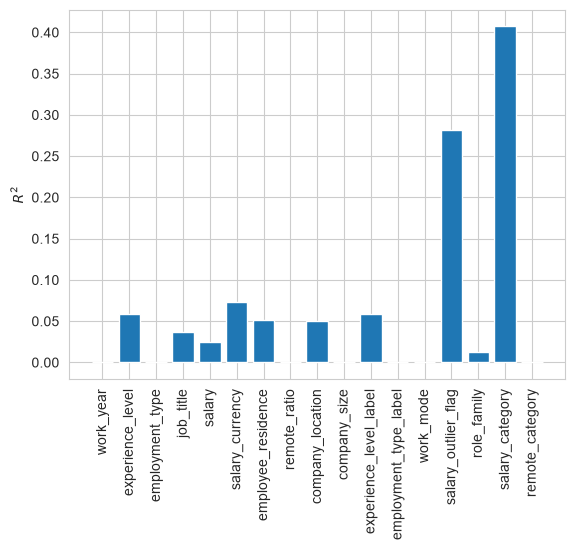

In [222]:
plt.bar(features,R_2_test)
plt.xticks(rotation=90)
plt.ylabel("$R^2$")
plt.show()

Now, we select the feature that works best, using `argmax()` function.

In [223]:
best=features[np.argmax(R_2_test)]
best

'salary_category'

So 'engineSize' is the best feature that produce the highest $R^(2)$. We then train the feature that works using all the data

In [224]:
pipe.fit(X[[best]],y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ss', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](1,)",['salary_category']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


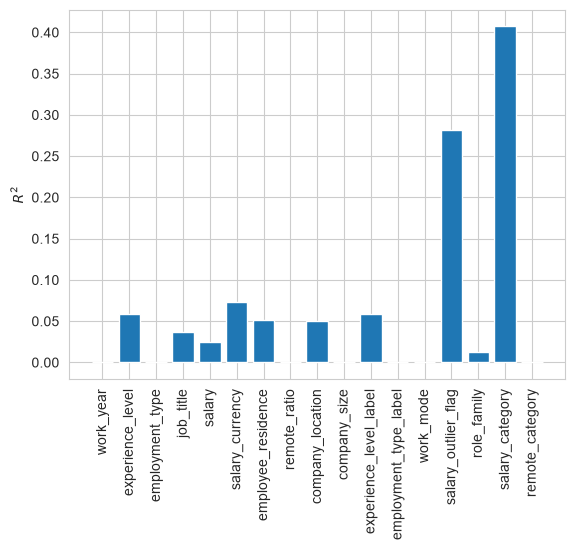

salary_category


In [225]:
R_2=[]

for feature in features:
      lr.fit(X_train[[feature]], y_train)
      R_2.append(lr.score(X_test[[feature]],y_test))
best=features[np.argmax(R_2)]
plt.bar(features,R_2)
plt.xticks(rotation=90)
plt.ylabel("$R^2$")
plt.show()
best=features[np.argmax(R_2)]
print(best)

## Cross Validation Score

Now, let's use *Scikit-Learn's* *K-fold cross-validation* method to see whether we can assess the performance of our model. The *K-fold cross-validation* method splits the training set into the number of folds (n_splits), as now in the Diagram above, if we have K folds, K-1 is used for training and one fold is used for testing. The input parameters are as follows:


<b>estimatorestimator</b>: The object to use to `fit` the data.

<b>X</b>: array-like of shape (n_samples, n_features). The data to fit. Can be for example a list, or an array.

<b>y</b>: array-like of shape (n_samples,) or (n_samples, n_outputs), default=None. The target variable to try to predict in the case of supervised learning.

<b>scoring</b>: A str or a scorer callable object/ function with signature scorer (estimator, X, y) which should return only a single value.  See model evaluation [documentation](https://scikit-learn.org/stable/modules/model_evaluation.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01#scoring-parameter) for more information.


In [226]:
N=len(X)
N

71913

Now, let's create a Linear Regression object.

Then, calculate cross validation scores based on our testing sets.

In [227]:
scores = cross_val_score(lr, X, y, scoring ="r2", cv=3)

We can calculate mean and standard deviation using the following function of the `scores`:

In [228]:
def display_scores(scores, print_=False):
    
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
    
display_scores(scores)

Scores: [0.47234815 0.46119107 0.45799517]
Mean: 0.46384479926746475
Standard deviation: 0.006152707383629567


result: 

* The larger the fold, the better the model performance is, as we are using more samples for training; the variance also decreases.

* Cross Validation Scores are RMSE values for training the data on each of our folds, in our case cv = 3, so we get 3 scores, 1 for each fold.

* in this case will need more feature to get better score 

The **engineSize** is the best feature that produce the highest $R^(2)$



In [229]:
Lasso(alpha=1.0).fit(X, y).coef_

array([ 7.87467048e+02,  8.19385895e+03,  5.14897033e+03,  4.28309812e+01,
        2.14957855e-02,  1.98898656e+03,  3.52911587e+02, -1.43132342e+02,
       -2.62542682e+02, -6.44342015e+02,  2.38884907e-01,  0.00000000e+00,
        1.04829180e+04,  2.21726454e+05,  1.92988437e+01, -4.27422909e+04,
        7.45735638e+02])

### Decision Tree Regressor

In [230]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create the model
model = DecisionTreeRegressor(random_state=0)

# Fit the model
model.fit(X_train, y_train)

# Make predictions using the test features
predictions = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 10644264.176601464
R-squared: 0.9982164426065967


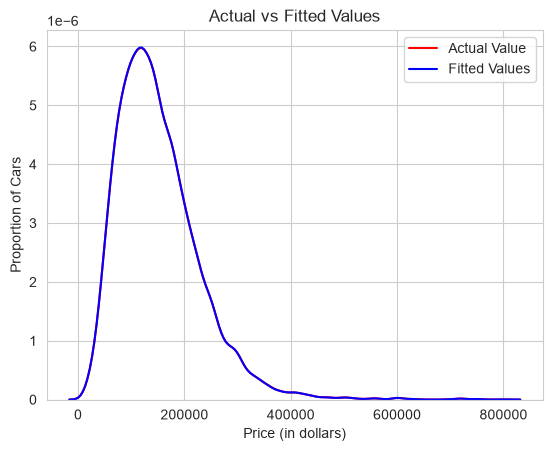

In [231]:
plot_dis(y_test,predictions)

In [232]:
model.feature_importances_

array([3.51854007e-05, 3.45596349e-06, 7.71113858e-09, 9.27310171e-06,
       8.24906299e-01, 4.54399789e-03, 6.10718297e-05, 5.88673510e-06,
       2.78045591e-05, 1.02442712e-06, 5.74404853e-06, 8.29285667e-08,
       2.25878344e-05, 1.33482668e-01, 8.52547841e-06, 3.68859807e-02,
       4.04221516e-07])

Compare the predicted data vs train train

In [233]:
def compare(y_test, predictions) :
  compare = pd.DataFrame()
  compare["Actual"] = y_test
  compare["Predict"] = predictions

  return compare

In [234]:
compare(y_test, predictions)

,Actual,Predict
54637,90900,90900.0
9937,256470,256500.0
58586,192986,192980.0
49544,185500,185500.0
33029,122500,122500.0
...,...,...
55758,150000,150000.0
52636,265000,265000.0
44127,82025,82048.0
36987,148700,148699.0


Build a prediction model test

In [235]:
X.iloc[11:12]

,work_year,experience_level,employment_type,job_title,salary,salary_currency,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,salary_category,remote_category
11,2025,3,2,89,113000,24,97,0,91,1,3,2,1,0,4,2,1


In [236]:
# will rondomly select the array to test the our model buld 
input_data = X.iloc[11:12]

#change the input data into numpy array
input_data_asnumpy_array = np.asanyarray(input_data)

#reshape the numpy array are we are insert new value for prediction
input_data_reshaped = input_data_asnumpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print('The predicted amount is',prediction)

The predicted amount is [113000.]


XGBOOSTER

In [237]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Define XGBoost model
# -----------------------------
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# -----------------------------
# Parameter grid
# -----------------------------
param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'n_estimators': [100, 200, 500]
}

# -----------------------------
# Grid search
# -----------------------------
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# -----------------------------
# Best parameters
# -----------------------------
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation MAE:")
print(-grid_search.best_score_)

# -----------------------------
# Predictions
# -----------------------------
train_predict = grid_search.predict(X_train)
val_predict = grid_search.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
train_mae = mean_absolute_error(y_train, train_predict)
val_mae = mean_absolute_error(y_test, val_predict)

train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
val_rmse = np.sqrt(mean_squared_error(y_test, val_predict))

r2_train = r2_score(y_train, train_predict)
r2_val = r2_score(y_test, val_predict)

print("\nModel Performance")
print("----------------------------")
print("Train MAE:  ", train_mae)
print("Validation MAE:", val_mae)

print("Train RMSE: ", train_rmse)
print("Validation RMSE:", val_rmse)

print("Train R²:   ", r2_train)
print("Validation R²:", r2_val)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters:
{'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.9}

Best Cross-Validation MAE:
786.9066772460938

Model Performance
----------------------------
Train MAE:   480.5586242675781
Validation MAE: 807.448486328125
Train RMSE:  1940.6889884780612
Validation RMSE: 4830.951873078431
Train R²:    0.9993706941604614
Validation R²: 0.9960894584655762


That's valid, but the plot is easier to interpret if you put actual values on the x-axis and predicted values on the y-axis, and add a 45-degree reference line.

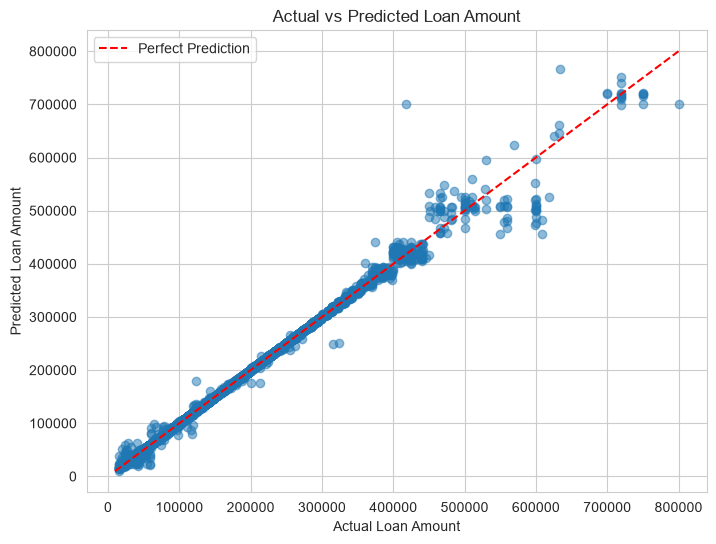

In [238]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    val_predict,
    alpha=0.5
)

# Perfect prediction line
min_value = min(y_test.min(), val_predict.min())
max_value = max(y_test.max(), val_predict.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color='red',
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted Loan Amount")
plt.legend()
plt.show()


If the predictions are perfect, all points would lie along the red dashed line.

### Actual vs predicted over observations
Your second plot is also useful:

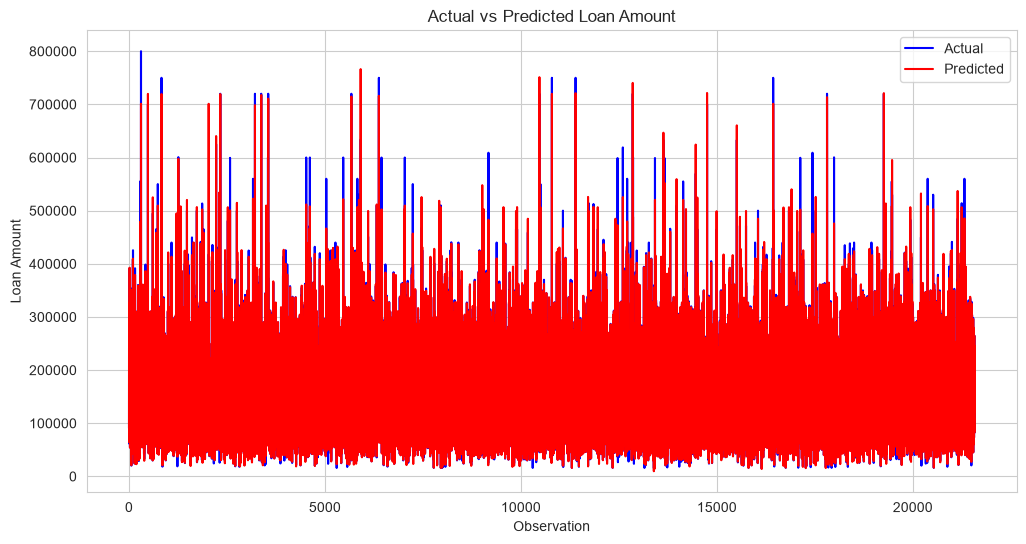

In [239]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values,
    color='blue',
    label='Actual'
)

plt.plot(
    val_predict,
    color='red',
    label='Predicted'
)

plt.title('Actual vs Predicted Loan Amount')
plt.xlabel('Observation')
plt.ylabel('Loan Amount')
plt.legend()
plt.show()


Save the model

In [240]:
import joblib

# Get the best XGBoost model
best_xgb_model = grid_search.best_estimator_

# Save the model
joblib.dump(best_xgb_model, 'xgboost_best_model.pkl')

print("XGBoost model saved successfully.")


XGBoost model saved successfully.
